In [1]:
from numba import cuda
print(cuda.is_available())


True


In [2]:
pip install numba numpy opencv-python


Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import cv2
import math
from numba import cuda

# -----------------------------
# 4K Image Size
# -----------------------------
HEIGHT = 4096
WIDTH = 4096

# -----------------------------
# Create sample RGB image
# -----------------------------
rgb_image = np.random.randint(0, 256, (HEIGHT, WIDTH, 3), dtype=np.uint8)

# Save sample image
cv2.imwrite("sample_rgb_4k.jpg", cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR))

# Output grayscale image
gray_image = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

# -----------------------------
# CUDA Kernel
# -----------------------------
@cuda.jit
def rgb_to_gray(rgb, gray):
    x, y = cuda.grid(2)

    if x < rgb.shape[0] and y < rgb.shape[1]:
        r = rgb[x, y, 0]
        g = rgb[x, y, 1]
        b = rgb[x, y, 2]

        # Grayscale formula
        gray[x, y] = int(0.299 * r + 0.587 * g + 0.114 * b)

# -----------------------------
# Copy data to GPU
# -----------------------------
d_rgb = cuda.to_device(rgb_image)
d_gray = cuda.to_device(gray_image)

# -----------------------------
# CUDA Grid setup
# -----------------------------
threads_per_block = (16, 16)
blocks_x = math.ceil(HEIGHT / threads_per_block[0])
blocks_y = math.ceil(WIDTH / threads_per_block[1])
blocks = (blocks_x, blocks_y)

# -----------------------------
# Launch kernel
# -----------------------------
rgb_to_gray[blocks, threads_per_block](d_rgb, d_gray)

# -----------------------------
# Copy back result
# -----------------------------
gray_image = d_gray.copy_to_host()

# -----------------------------
# Save grayscale image
# -----------------------------
cv2.imwrite("grayscale_4k.jpg", gray_image)

print("Done!")
print("Saved: sample_rgb_4k.jpg")
print("Saved: grayscale_4k.jpg")


Done!
Saved: sample_rgb_4k.jpg
Saved: grayscale_4k.jpg


In [5]:
import torch
import cv2
import numpy as np

# 4K Image
H, W = 4096, 4096
rgb = torch.randint(0, 256, (H, W, 3), device="cuda", dtype=torch.float32)

# RGB -> Gray
gray = 0.299*rgb[:,:,0] + 0.587*rgb[:,:,1] + 0.114*rgb[:,:,2]

# Save images
rgb_cpu = rgb.byte().cpu().numpy()
gray_cpu = gray.byte().cpu().numpy()

cv2.imwrite("sample_rgb_4k.jpg", cv2.cvtColor(rgb_cpu, cv2.COLOR_RGB2BGR))
cv2.imwrite("grayscale_4k.jpg", gray_cpu)

print("Saved images using Kaggle GPU!")


Saved images using Kaggle GPU!


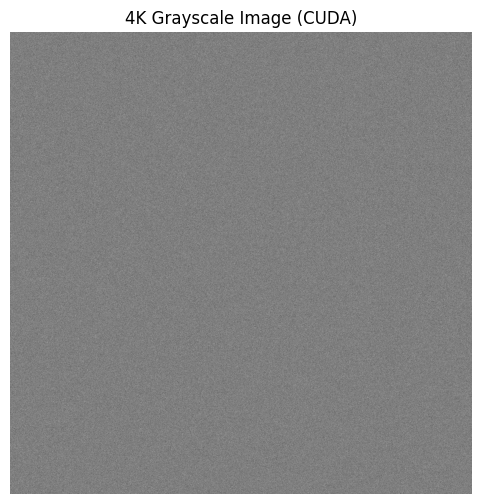

In [6]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Create 4K RGB image on GPU
# -----------------------------
H, W = 4096, 4096
rgb = torch.randint(0, 256, (H, W, 3), device="cuda", dtype=torch.float32)

# -----------------------------
# Convert RGB -> Gray on GPU
# -----------------------------
gray = 0.299*rgb[:,:,0] + 0.587*rgb[:,:,1] + 0.114*rgb[:,:,2]

# -----------------------------
# Move to CPU
# -----------------------------
rgb_cpu = rgb.byte().cpu().numpy()
gray_cpu = gray.byte().cpu().numpy()

# -----------------------------
# Display
# -----------------------------
plt.figure(figsize=(6,6))
plt.imshow(gray_cpu, cmap="gray")
plt.title("4K Grayscale Image (CUDA)")
plt.axis("off")
plt.show()


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# Load real image
# -----------------------------
img = cv2.imread("/kaggle/input/sample-images/lena.png")  # change path if needed
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (4096, 4096))

H, W, _ = img.shape

# -----------------------------
# CPU Grayscale
# -----------------------------
start = time.time()
gray_cpu = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]).astype(np.uint8)
cpu_time = time.time() - start

# -----------------------------
# GPU Grayscale (CUDA)
# -----------------------------
img_t = torch.from_numpy(img).float().cuda()

start = time.time()
gray_gpu = 0.299*img_t[:,:,0] + 0.587*img_t[:,:,1] + 0.114*img_t[:,:,2]
torch.cuda.synchronize()
gpu_time = time.time() - start

gray_gpu = gray_gpu.byte().cpu().numpy()

# -----------------------------
# Show side by side
# -----------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_gpu, cmap="gray")
plt.title("Grayscale (CUDA)")
plt.axis("off")

plt.show()

# -----------------------------
# Print timing
# -----------------------------
print(f"CPU Time: {cpu_time:.4f} seconds")
print(f"GPU Time: {gpu_time:.4f} seconds")


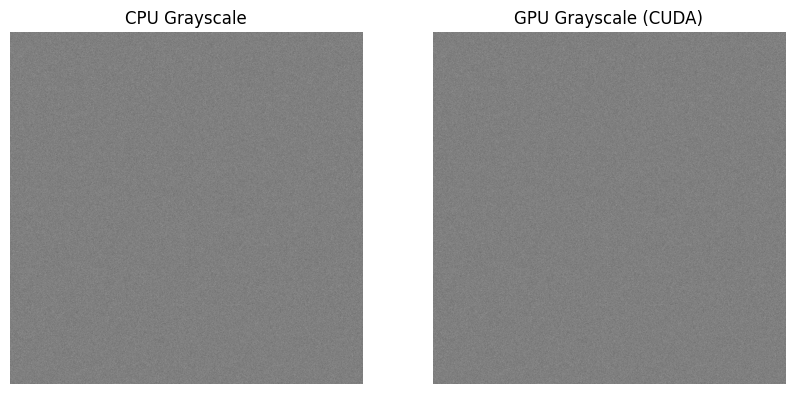

CPU Time: 0.12517 seconds
GPU Time: 0.00511 seconds


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# Create 4K RGB image

H, W = 4096, 4096
rgb_gpu = torch.randint(0, 256, (H, W, 3), device="cuda", dtype=torch.float32)

# Copy for CPU
rgb_cpu = rgb_gpu.cpu().numpy().astype(np.float32)


# GPU Grayscale

start = time.time()
gray_gpu = 0.299*rgb_gpu[:,:,0] + 0.587*rgb_gpu[:,:,1] + 0.114*rgb_gpu[:,:,2]
torch.cuda.synchronize()
gpu_time = time.time() - start

gray_gpu_img = gray_gpu.byte().cpu().numpy()


# CPU Grayscale

start = time.time()
gray_cpu = (0.299*rgb_cpu[:,:,0] + 
            0.587*rgb_cpu[:,:,1] + 
            0.114*rgb_cpu[:,:,2]).astype(np.uint8)
cpu_time = time.time() - start


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray_cpu, cmap="gray")
plt.title("CPU Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_gpu_img, cmap="gray")
plt.title("GPU Grayscale (CUDA)")
plt.axis("off")

plt.show()

print(f"CPU Time: {cpu_time:.5f} seconds")
print(f"GPU Time: {gpu_time:.5f} seconds")
